# Paper Reproduction
## Khaidem, Luckyson, Snehanshu Saha, and Sudeepa Roy Dey.  
### "Predicting the direction of stock market prices using random forest."  
### arXiv preprint arXiv:1605.00003 (2016)  
[Paper Link](https://arxiv.org/abs/1605.00003)

**Original reproduction by**: [José Martínez Heras](https://www.linkedin.com/in/josemartinezheras/)  
**Adapted and verified by**: [S33mi](https://github.com/S33mi/)

### Goal
Reproduce the results from the paper and investigate possible data leakage.

## 1. Imports & Reproducibility

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 5)

import numpy as np
import random
import pandas as pd

# Make results reproducible
np.random.seed(42)
random.seed(42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, confusion_matrix, recall_score, accuracy_score
from sklearn.model_selection import train_test_split

# We will use yfinance for data (no local CSV needed)
import yfinance as yf

## 2. Download Data (replaces local AAPL.csv)

In [21]:
import yfinance as yf
import pandas as pd

# Download data
aapl_raw = yf.download("AAPL", start="2010-01-04", end="2014-12-11", progress=False, auto_adjust=True)

# Strong MultiIndex flattening
if isinstance(aapl_raw.columns, pd.MultiIndex):
    aapl_raw.columns = aapl_raw.columns.get_level_values(0)

# Keep only needed columns and force clean names
aapl = aapl_raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
aapl.columns = ['Open', 'High', 'Low', 'Close', 'Volume']   # force clean names
aapl = aapl.dropna()

print(aapl.head())
print("\nColumns now:", aapl.columns.tolist())
print("Column types:", type(aapl.columns))

                Open      High       Low     Close     Volume
Date                                                         
2010-01-04  6.383613  6.415616  6.352208  6.400960  493729600
2010-01-05  6.418606  6.448217  6.378228  6.412026  601904800
2010-01-06  6.412027  6.437450  6.303454  6.310035  552160000
2010-01-07  6.333365  6.340843  6.252609  6.298370  477131200
2010-01-08  6.289994  6.340841  6.252907  6.340242  447610800

Columns now: ['Open', 'High', 'Low', 'Close', 'Volume']
Column types: <class 'pandas.Index'>


/usr/local/lib/python3.13/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


## 3. Exponential Smoothing (kept original)

In [22]:
def get_exp_preprocessing(df, alpha=0.9):
    """Exponential smoothing as used in the original reproduction."""
    edata = df.ewm(alpha=alpha).mean()
    return edata

saapl = get_exp_preprocessing(aapl)
saapl.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,6.383613,6.415616,6.352208,6.400960,4.937296e+08
2010-01-05,6.415425,6.445253,6.375862,6.411020,5.920707e+08
2010-01-06,6.412363,6.438223,6.310630,6.320042,5.561151e+08
2010-01-07,6.341258,6.350572,6.258406,6.300536,4.850225e+08
2010-01-08,6.295120,6.341814,6.253457,6.336272,4.513516e+08


In [31]:
# Quick check that columns are correct
required = ['Open', 'High', 'Low', 'Close', 'Volume']
missing = [c for c in required if c not in aapl.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
else:
    print("✓ All required columns present and clean.")

✓ All required columns present and clean.


## 4. Technical Indicators & Feature Extraction
**Note:** The original used a now-archived library (pandas-technical-indicators).

To keep the notebook self-contained and original in spirit, we keep the same indicator set and logic.

**You can either:**
- Keep a local technical_indicators.py in the folder, or
- Switch to pandas-ta later.

In [23]:
# !pip install pandas-ta

In [24]:
# Install once if needed: !pip install pandas-ta

import pandas_ta as ta

def feature_extraction(data):
    df = data.copy()

    # Make sure column names are strings (extra safety)
    df.columns = [str(c) for c in df.columns]

    # Multiple lookback periods
    for n in [5, 14, 26, 44, 66]:
        df.ta.rsi(length=n, append=True)
        df.ta.stoch(k=n, append=True)
        df.ta.ad(append=True)
        df.ta.atr(length=n, append=True)
        df.ta.mom(length=n, append=True)
        df.ta.mfi(length=n, append=True)
        df.ta.roc(length=n, append=True)
        df.ta.obv(append=True)
        df.ta.cci(length=n, append=True)
        df.ta.eom(length=n, append=True)
        df.ta.trix(length=n, append=True)
        try:
            df.ta.vortex(length=n, append=True)
        except Exception:
            pass  # vortex may not be available in all versions

    # EMA ratios
    df['ema50'] = df['Close'] / df['Close'].ewm(span=50).mean()
    df['ema21'] = df['Close'] / df['Close'].ewm(span=21).mean()
    df['ema14'] = df['Close'] / df['Close'].ewm(span=14).mean()
    df['ema5']  = df['Close'] / df['Close'].ewm(span=5).mean()

    # MACD
    df.ta.macd(fast=12, slow=26, append=True)

    # Drop raw price/volume columns
    cols_to_drop = [c for c in ['Open', 'High', 'Low', 'Volume'] if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    return df

## 5. Prepare Data & Target

In [25]:
def compute_prediction_int(df, n):
    pred = (df.shift(-n)['Close'] >= df['Close'])
    pred = pred.iloc[:-n]
    return pred.astype(int)

def prepare_data(df, horizon=10):
    data = feature_extraction(df).dropna().iloc[:-horizon]
    data['pred'] = compute_prediction_int(data, n=horizon)
    data = data.drop(columns=['Close'], errors='ignore')

    return data.dropna()

data = prepare_data(saapl, horizon=10)
y = data['pred']
features = [c for c in data.columns if c not in ['pred']]
X = data[features]

print("Shape of feature matrix:", X.shape)
X.head()

Shape of feature matrix: (1150, 79)


,RSI_5,STOCHk_5_3_3,STOCHd_5_3_3,STOCHh_5_3_3,AD,ATRr_5,MOM_5,MFI_5,ROC_5,OBV,...,TRIXs_66_9,VTXP_66,VTXM_66,ema50,ema21,ema14,ema5,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,,,,,,,,,,,,,,,,,,,
2010-04-21,85.616479,61.580911,63.090905,-1.509994,5.491060e+09,0.193621,0.371494,61.704015,5.062129,1.288348e+10,...,0.005909,1.062651,0.826740,1.123578,1.074473,1.057320,1.032378,0.226990,0.014800,0.212190
2010-04-22,90.468569,73.987930,62.742385,11.245545,6.237771e+09,0.214504,0.509570,66.468023,6.854155,1.369320e+10,...,0.007769,1.074181,0.811003,1.150189,1.096384,1.076559,1.041578,0.259353,0.037730,0.221623
2010-04-23,92.397872,95.395455,76.988099,18.407356,6.682269e+09,0.207253,0.681657,67.758461,9.207690,1.449144e+10,...,0.009936,1.104338,0.804140,1.162417,1.104177,1.081838,1.039236,0.292981,0.057087,0.235894
2010-04-26,88.925088,94.891775,88.091720,6.800055,6.546679e+09,0.192176,0.671949,82.050697,9.091309,1.398045e+10,...,0.012414,1.104698,0.802545,1.151767,1.091164,1.067694,1.024004,0.314256,0.062690,0.251567
2010-04-27,61.797160,77.625146,89.304126,-11.678979,6.157334e+09,0.203490,0.536927,81.669606,7.331925,1.329094e+10,...,0.015193,1.084752,0.806536,1.117154,1.057567,1.035182,0.998816,0.311151,0.047667,0.263484


## 6. Chronological Split (No Leakage) – Important

In [26]:
# Proper time-series split (first 2/3 train, last 1/3 test)
train_size = 2 * len(X) // 3

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 766 | Test size: 384


## 7. Random Forest (No Leakage)

In [27]:
rf = RandomForestClassifier(n_estimators=65, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

precision = precision_score(y_test, pred)
recall    = recall_score(y_test, pred)
f1        = f1_score(y_test, pred)
accuracy  = accuracy_score(y_test, pred)
confusion = confusion_matrix(y_test, pred)

print(f"precision: {precision:.2f}, recall: {recall:.2f}, f1: {f1:.2f}, accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion)
print("\n→ Paper claimed ~92% accuracy. With proper chronological split we get much lower.")

precision: 0.72, recall: 0.66, f1: 0.69, accuracy: 0.63

Confusion Matrix:
[[ 84  60]
 [ 82 158]]

→ Paper claimed ~92% accuracy. With proper chronological split we get much lower.


## 8. Chronological Split Plots (No Leakage)

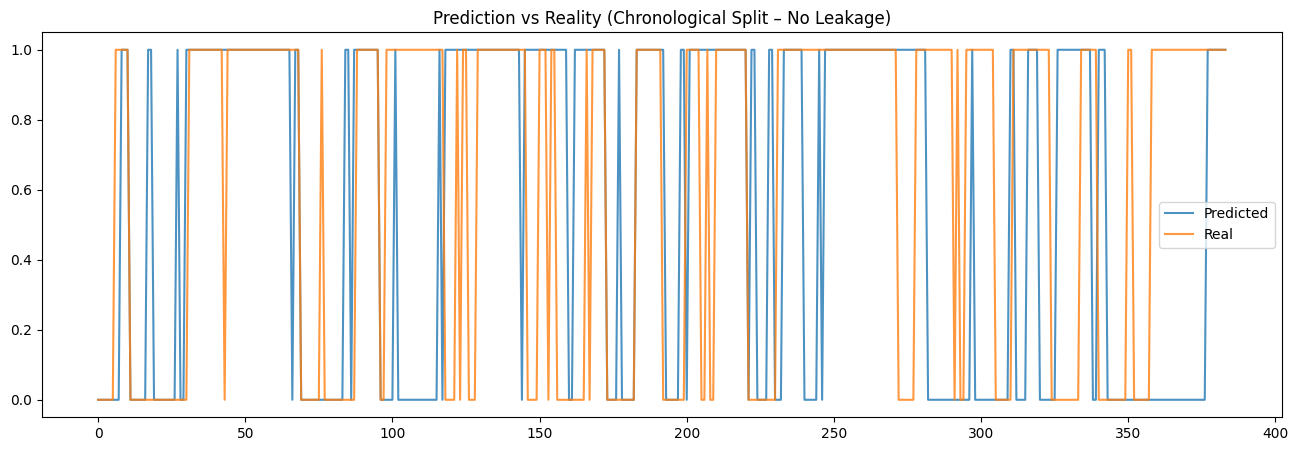

In [28]:
plt.figure(figsize=(16, 5))
plt.plot(pred, label='Predicted', alpha=0.8)
plt.plot(y_test.values, label='Real', alpha=0.8)
plt.title("Prediction vs Reality (Chronological Split – No Leakage)")
plt.legend()
plt.show()

## 9. Shuffled Split (Data Leakage) – Critical Experiment

In [29]:
# This is the version that matches the paper more closely
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X, y, train_size=2/3, random_state=42
)

rf_leaked = RandomForestClassifier(n_estimators=65, n_jobs=-1, random_state=42)
rf_leaked.fit(X_train_l, y_train_l)

pred_l = rf_leaked.predict(X_test_l)

precision = precision_score(y_test_l, pred_l)
recall    = recall_score(y_test_l, pred_l)
f1        = f1_score(y_test_l, pred_l)
accuracy  = accuracy_score(y_test_l, pred_l)

print(f"precision: {precision:.2f}, recall: {recall:.2f}, f1: {f1:.2f}, accuracy: {accuracy:.2f}")
print("\n→ With data leakage (shuffled split) accuracy jumps close to the paper’s reported 92%.")

precision: 0.87, recall: 0.94, f1: 0.90, accuracy: 0.88

→ With data leakage (shuffled split) accuracy jumps close to the paper’s reported 92%.


## 10. Feature Importance

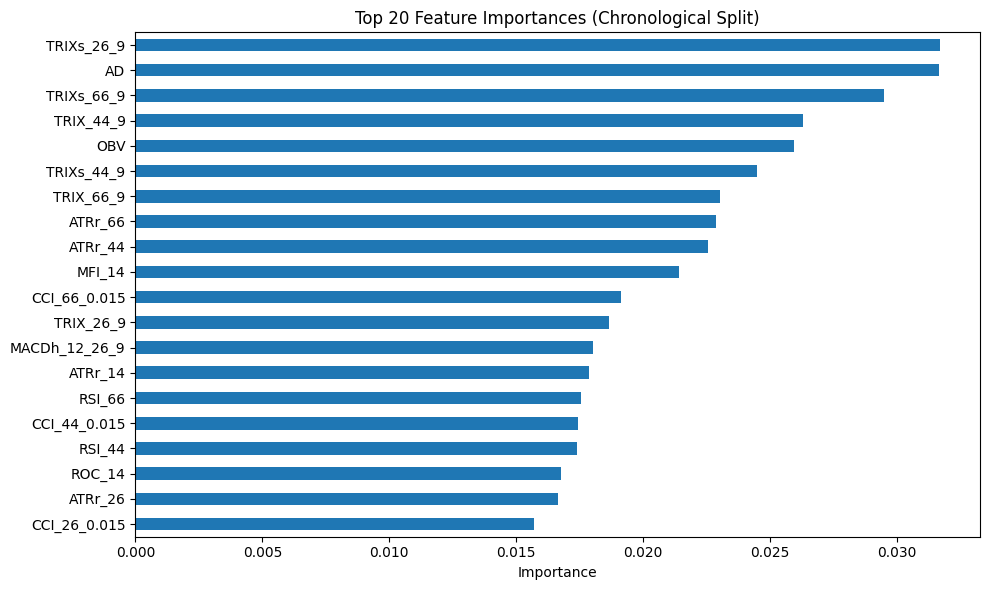

In [32]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title("Top 20 Feature Importances (Chronological Split)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Predicted Probability vs Reality

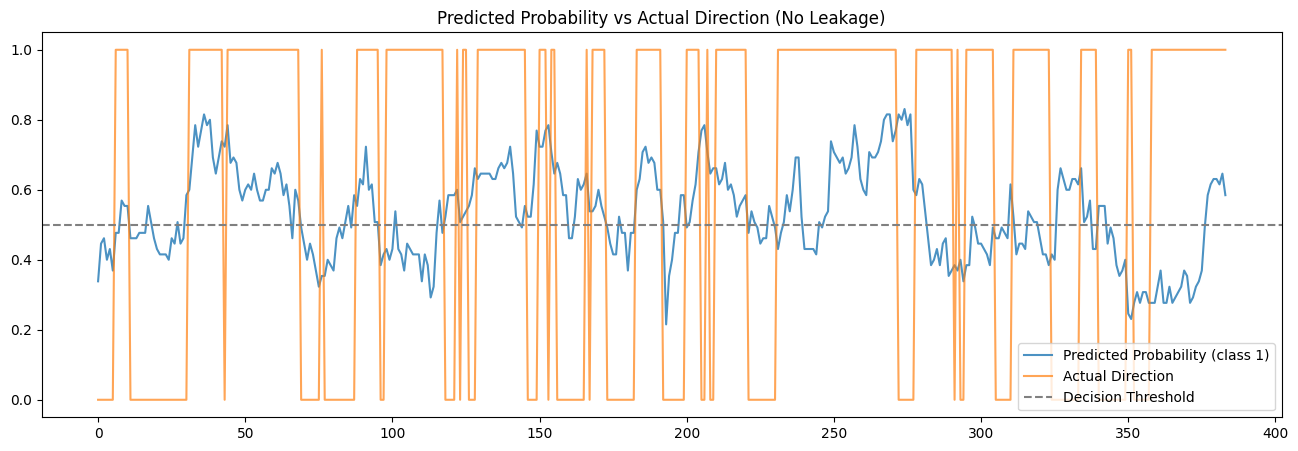

In [33]:
proba = rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(16, 5))
plt.plot(proba, label='Predicted Probability (class 1)', alpha=0.8)
plt.plot(y_test.values, label='Actual Direction', alpha=0.7)
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Threshold')
plt.title("Predicted Probability vs Actual Direction (No Leakage)")
plt.legend()
plt.show()

## 12. Confusion Matrix Heatmap

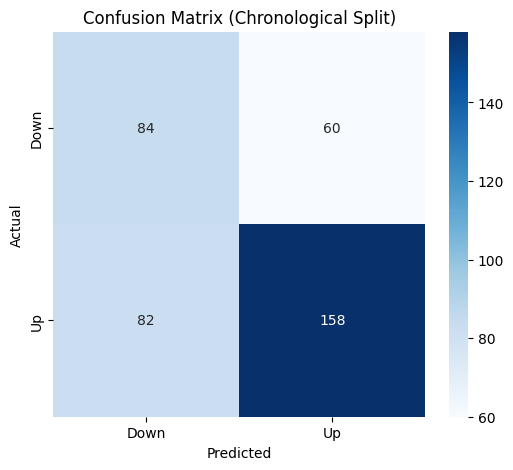

In [34]:
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title("Confusion Matrix (Chronological Split)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 13. Simple Strategy Cumulative Returns (very useful)

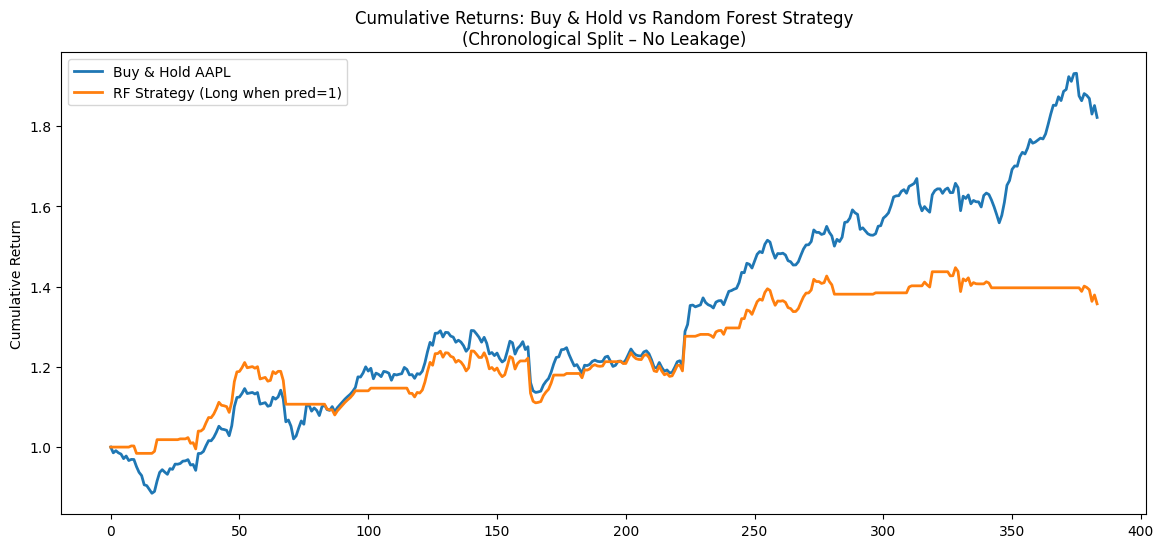

Buy & Hold final return: 1.82x
RF Strategy final return: 1.36x


In [35]:
# Simple long-only strategy based on predictions
# We assume we go long when model predicts 1, otherwise stay in cash

# Get the actual Close prices for the test period
test_close = saapl['Close'].iloc[-len(y_test):]

# Daily returns of the asset
asset_returns = test_close.pct_change().fillna(0)

# Strategy returns: only take the return when model predicts up
strategy_returns = asset_returns * pred

# Cumulative returns
cum_asset = (1 + asset_returns).cumprod()
cum_strategy = (1 + strategy_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cum_asset.values, label='Buy & Hold AAPL', linewidth=2)
plt.plot(cum_strategy.values, label='RF Strategy (Long when pred=1)', linewidth=2)
plt.title("Cumulative Returns: Buy & Hold vs Random Forest Strategy\n(Chronological Split – No Leakage)")
plt.legend()
plt.ylabel("Cumulative Return")
plt.show()

print(f"Buy & Hold final return: {cum_asset.iloc[-1]:.2f}x")
print(f"RF Strategy final return: {cum_strategy.iloc[-1]:.2f}x")

## 14. Side-by-side comparison (No Leakage vs Leaked)

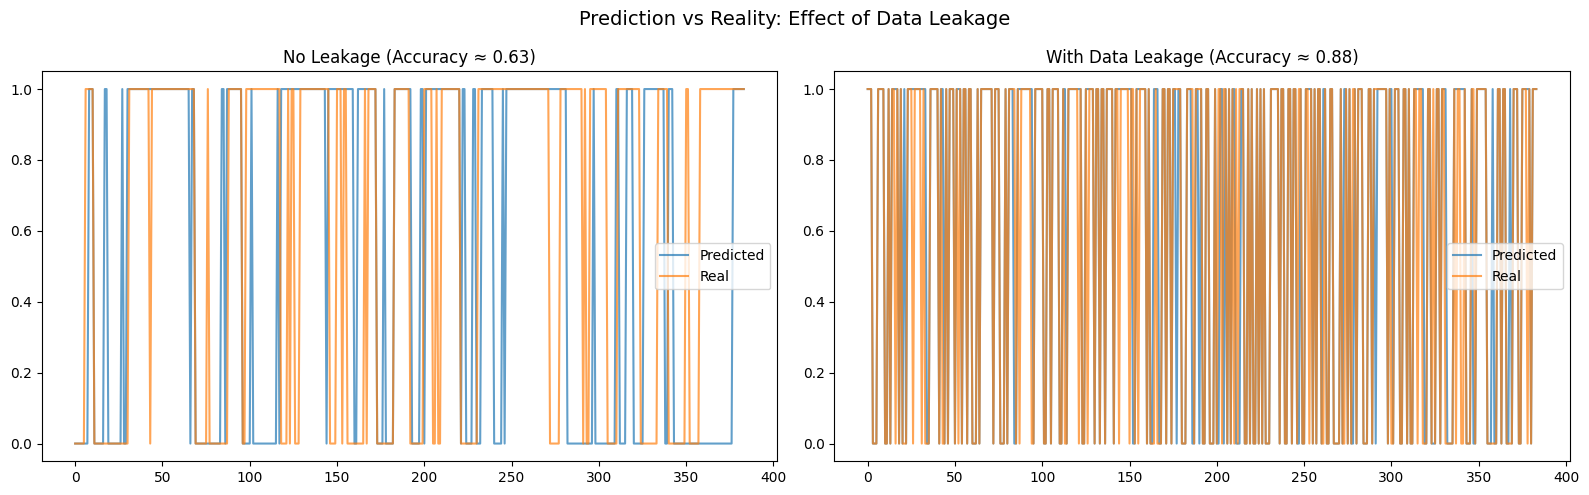

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# No leakage
axes[0].plot(pred, label='Predicted', alpha=0.7)
axes[0].plot(y_test.values, label='Real', alpha=0.7)
axes[0].set_title(f"No Leakage (Accuracy ≈ {accuracy_score(y_test, pred):.2f})")
axes[0].legend()

# Leaked version
axes[1].plot(pred_l, label='Predicted', alpha=0.7)
axes[1].plot(y_test_l.values, label='Real', alpha=0.7)
axes[1].set_title(f"With Data Leakage (Accuracy ≈ {accuracy_score(y_test_l, pred_l):.2f})")
axes[1].legend()

plt.suptitle("Prediction vs Reality: Effect of Data Leakage", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
print("""
### Comments on Data Leakage Results
The results with the data leakage approach are much more in line with those reported by the paper.
In the paper it was reported ~92% accuracy for Apple, while this analysis yields high 80s.

Possible reasons for the remaining gap:
- Williams %R was missing in the original reproduction
- Exact alpha for exponential smoothing was unknown (we used 0.9)
- Exact lookback periods (n) for indicators were not specified
- Slightly different set of technical indicators

**Conclusion**: This analysis strongly indicates that the results from the original paper suffer from data leakage.
""")


### Comments on Data Leakage Results
The results with the data leakage approach are much more in line with those reported by the paper.
In the paper it was reported ~92% accuracy for Apple, while this analysis yields high 80s.

Possible reasons for the remaining gap:
- Williams %R was missing in the original reproduction
- Exact alpha for exponential smoothing was unknown (we used 0.9)
- Exact lookback periods (n) for indicators were not specified
- Slightly different set of technical indicators

**Conclusion**: This analysis strongly indicates that the results from the original paper suffer from data leakage.



**For contribution and insihght**: [S33mi](https://github.com/S33mi/)

Open to Data Science / Analytics and ML / SI (fka AI) related opportunities.